# Bengali NLP : Sentiment & Emotion Classification

This notebook performs **text preprocessing** and **classification modeling**
on Bengali social media text.

## Pipeline
1. Load cleaned data (from EDA notebook)
2. Noise detection & text cleaning
3. Feature extraction using TF-IDF (custom Bengali tokenizer)
4. Sentiment classification : Logistic Regression & LinearSVC
5. Emotion classification : Logistic Regression & LinearSVC
6. Evaluation : CV, Classification Report, Confusion Matrix, ROC Curve

In [1]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/clean_data.csv')
pd.set_option('display.max_colwidth', None)
df.head()

,Text,Sentiment,Emotion,text_length,word_count
0,"এসব পাছা কবিরের আজাইররা পোস্ট। হেতি ক, ""যদি ভুল করে থাকি!! "" কত্ত বড় হারামজাদি ইতে!! উষ্ঠা মারা উচিত হেতিরে।",Negative,Creepy,110,20
1,জুতা মারি গরুদান মারান!! আপনার আম্মা আব্বার খেলা দেখে কি সিউর হইছিলেন আপনি তাদেরই মেয়ে???,Strongly Negative,Creepy,89,15
2,"সুখে থাকতে ভুতে কিলাই, প্রবাদটা এর কাজের দ্বারা আবারো প্রমানিত। এর অভিযোগের বাস্তবতা ওরে দিয়েই বাস্তবায়ন করা হোক।",Negative,Bullying,113,18
3,তর মাথায় ব্রেন আছে সেটা তুই দেখছস? না দেখলে ভাব্বি গবর আছে,Strongly Negative,Bullying,58,12
4,আপনি কি নাস্তিক..?,Negative,Unbiased,18,3


In [3]:
df.shape

(5635, 5)

## 1. Noise Detection

Before cleaning, we verify what types of noise exist in the raw text:
- **URLs** - links add no sentiment value
- **Emojis** - outside Bengali Unicode block
- **Special punctuation/symbols** - non-Bengali characters

This step confirms what the `clean_text()` function needs to handle.

In [4]:
import re


# URL Detection
url_pattern = r'http\S+|www\S+'

url_count = df['Text'].str.contains(url_pattern, regex=True).sum()
print(f"Rows containing URLs: {url_count}")


# Actual Emoji Detection
actual_emoji = re.compile(r'[\U0001F300-\U0001FFFF]')

emoji_only_count = df['Text'].apply(
    lambda x: bool(actual_emoji.search(str(x)))
).sum()

print(f"Rows containing actual emojis: {emoji_only_count}")


# Special Punctuation Detection
# (excluding emojis)
punct_pattern = re.compile(
    r'[^\u0980-\u09FF\u0000-\u007F\s\U0001F300-\U0001FFFF]'
)

punct_count = df['Text'].apply(
    lambda x: bool(punct_pattern.search(str(x)))
).sum()

print(f"Rows containing special punctuation/symbols: {punct_count}")

# URL Example
print("\nURL Example:")

url_rows = df[df['Text'].str.contains(url_pattern, regex=True)]

if len(url_rows) > 0:
    print(url_rows['Text'].iloc[0])
else:
    print("No URL found")

# Actual Emoji Example
print("\nActual Emoji Example:")

emoji_rows = df[df['Text'].apply(
    lambda x: bool(actual_emoji.search(str(x)))
)]

if len(emoji_rows) > 0:
    print(emoji_rows['Text'].iloc[0])
else:
    print("No actual emoji found")

# Special Punctuation Example
print("\nSpecial Punctuation Example:")

punct_rows = df[df['Text'].apply(
    lambda x: bool(punct_pattern.search(str(x)))
)]

if len(punct_rows) > 0:
    print(punct_rows['Text'].iloc[0])
else:
    print("No special punctuation found")

Rows containing URLs: 18
Rows containing actual emojis: 31
Rows containing special punctuation/symbols: 2296

URL Example:
সবাই প্রতিবাদ করুন নিচের লিংকে গিয়ে..... https://www.facebook.com/abc4utah/videos/2301600330105127/?fref=mentions

Actual Emoji Example:
খানকিদের লিস্টে তুই সবার উপর থাকবি 🖕🖕🖕🖕🖕

Special Punctuation Example:
এসব পাছা কবিরের আজাইররা পোস্ট। হেতি ক, "যদি ভুল করে থাকি!! " কত্ত বড় হারামজাদি ইতে!!  উষ্ঠা মারা উচিত হেতিরে।


### 2. Text Cleaning

We apply a `clean_text()` function to each row that removes:
- URLs and emojis
- All non-Bengali characters (English letters, symbols, punctuation)
- Bengali digits (০-৯) and English digits
- Extra whitespace


In [30]:
def clean_text(text):

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove emojis
    text = re.sub(r'[\U0001F300-\U0001FFFF]', '', text)
    text = re.sub(r'[^\u0980-\u09FF\s]', '', text)
    text = re.sub(r'[।৷]', '', text)
    # Bengali & English numbers remove
    text = re.sub(r'[০-৯\d]+', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_text'] = df['Text'].apply(clean_text)

# Before vs After
emoji_rows = df[df['Text'].str.contains(r'[\U0001F300-\U0001FFFF]', regex=True)]
idx = emoji_rows.index[0:4]

print("BEFORE:", df['Text'].iloc[idx])
print("AFTER: ", df['clean_text'].iloc[idx])

BEFORE: 69                            খানকিদের লিস্টে তুই সবার উপর থাকবি 🖕🖕🖕🖕🖕
260                                        সত্য বলার কলিজা বহাল রাখুন👍
261    হা হা হা ইম্রান এইডসের শিশ্য রাজাকারের ছানা 😜 হা হা হা মগাই মগা
262                সত্য বলার এই কলিজা সবসময় রাখুন সত্যের জয় অনিবার্য 👍
Name: Text, dtype: object
AFTER:  69                                খানকিদের লিস্টে তুই সবার উপর থাকবি
260                                       সত্য বলার কলিজা বহাল রাখুন
261    হা হা হা ইম্রান এইডসের শিশ্য রাজাকারের ছানা হা হা হা মগাই মগা
262                সত্য বলার এই কলিজা সবসময় রাখুন সত্যের জয় অনিবার্য
Name: clean_text, dtype: object


In [6]:
df['clean_text'].head()

,clean_text
0,এসব পাছা কবিরের আজাইররা পোস্ট হেতি ক যদি ভুল করে থাকি কত্ত বড় হারামজাদি ইতে উষ্ঠা মারা উচিত হেতিরে
1,জুতা মারি গরুদান মারান আপনার আম্মা আব্বার খেলা দেখে কি সিউর হইছিলেন আপনি তাদেরই মেয়ে
2,সুখে থাকতে ভুতে কিলাই প্রবাদটা এর কাজের দ্বারা আবারো প্রমানিত এর অভিযোগের বাস্তবতা ওরে দিয়েই বাস্তবায়ন করা হোক
3,তর মাথায় ব্রেন আছে সেটা তুই দেখছস না দেখলে ভাব্বি গবর আছে
4,আপনি কি নাস্তিক


## 3. Feature Extraction : TF-IDF

Converting cleaned Bengali text into numerical features using TF-IDF.

**Why custom tokenizer?**  
Default `token_pattern` uses `\b` word boundary which does not work
for Unicode Bengali characters. Our tokenizer:
- Extracts only Bengali Unicode block characters (`\u0980-\u09FF`)
- Filters tokens shorter than 2 characters (removes noise like "ঃ")
- Captures unigrams and bigrams via `ngram_range=(1,2)`

In [7]:
from sklearn.feature_extraction.text  import TfidfVectorizer

import re

def bengali_tokenizer(text):
    tokens = re.findall(r'[\u0980-\u09FF]+', text)
    tokens = [t for t in tokens if len(t) >= 2]
    return tokens

tfidf = TfidfVectorizer(
    max_features=8000,
    min_df=2,
    tokenizer=bengali_tokenizer,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df['clean_text'])
print("Shape:", X.shape)

Shape: (5635, 8000)


In [8]:
print(tfidf.get_feature_names_out())

['অংশ' 'অংশ দেখেও' 'অই' ... 'হয়েছে তাই' 'হয়েছে তার' 'হয়েছে ধন্যবাদ']


In [9]:
features = tfidf.get_feature_names_out()
print("First 20 features:", features[:20])

First 20 features: ['অংশ' 'অংশ দেখেও' 'অই' 'অক্লান্ত' 'অক্লান্ত প্রচেষ্টায়' 'অক্সিজেন'
 'অগনিত' 'অগ্রিম' 'অতঃপর' 'অতএব' 'অতপর' 'অতি' 'অতি উত্তেজিত' 'অতীতের'
 'অতুলনীয়' 'অত্যন্ত' 'অত্যন্ত ক্ষমাশীল' 'অত্যাচার' 'অথচ' 'অথবা']


In [10]:
!pip install bnlp_toolkit

import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [11]:
features = tfidf.get_feature_names_out()

from bnlp.corpus.corpus import bengali_stopwords
sw_set = set(bengali_stopwords)

stopword_features = [f for f in features if f in sw_set]
content_features = [f for f in features if f not in sw_set]

print(f"Total features: {len(features)}")
print(f"Stopword features: {len(stopword_features)}")
print(f"Content features: {len(content_features)}")
print(f"\nSample stopwords in your TF-IDF matrix:")
print(stopword_features[:20])

Total features: 8000
Stopword features: 300
Content features: 7700

Sample stopwords in your TF-IDF matrix:
['অতএব', 'অথচ', 'অথবা', 'অনেক', 'অনেকে', 'অনেকেই', 'অন্তত', 'অন্য', 'অবশ্য', 'আই', 'আগামী', 'আগে', 'আগেই', 'আছে', 'আজ', 'আপনার', 'আপনি', 'আবার', 'আমরা', 'আমাকে']


In [12]:
negation_words = ['না', 'নয়', 'নেই']
for w in negation_words:
    print(f'"{w}" feature হিসেবে আছে: {w in features}')

"না" feature হিসেবে আছে: True
"নয়" feature হিসেবে আছে: True
"নেই" feature হিসেবে আছে: True


# **Sentiment Classification**

## 4. Sentiment Classification

**Target:** Predict one of 5 sentiment classes:  
`Negative` | `Neutral` | `Positive` | `Strongly Negative` | `Strongly Positive`

**Strategy:**
- Label encode target variable
- Stratified 80/20 train-test split
- 5-Fold Stratified Cross Validation before final training
- Compare Logistic Regression vs LinearSVC
- Final evaluation on held-out test set

Label Encoding

In [13]:
from sklearn.preprocessing import LabelEncoder

le_sentiment = LabelEncoder()
y_sentiment = le_sentiment.fit_transform(df['Sentiment'])

print("Sentiment Classes:", le_sentiment.classes_)
print("Sample labels:", y_sentiment[:5])

Sentiment Classes: ['Negative' 'Neutral' 'Positive' 'Strongly Negative' 'Strongly Positive']
Sample labels: [0 3 0 3 0]


Train/Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_sentiment,
    test_size=0.2,
    random_state=42,
    stratify=y_sentiment
)

print("Train size:", X_train_s.shape)
print("Test size:", X_test_s.shape)

Train size: (4508, 8000)
Test size: (1127, 8000)


Cross Validation

In [15]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression CV
lr_cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_train_s, y_train_s,
    cv=skf,
    scoring='f1_weighted'
)

print("LR CV F1 scores:", lr_cv_scores)
print("LR Mean F1:", lr_cv_scores.mean().round(4))
print("LR Std:", lr_cv_scores.std().round(4))

LR CV F1 scores: [0.60326314 0.57152058 0.61903704 0.58366269 0.59094858]
LR Mean F1: 0.5937
LR Std: 0.0163


In [16]:
from sklearn.svm import LinearSVC

svm_cv_scores = cross_val_score(
    LinearSVC(max_iter=1000),
    X_train_s, y_train_s,
    cv=skf,
    scoring='f1_weighted'
)

print("SVM CV F1 scores:", svm_cv_scores)
print("SVM Mean F1:", svm_cv_scores.mean().round(4))
print("SVM Std:", svm_cv_scores.std().round(4))

SVM CV F1 scores: [0.5846824  0.58948295 0.60599052 0.55889326 0.58613768]
SVM Mean F1: 0.585
SVM Std: 0.0151


Train Model

In [17]:
from sklearn.metrics import classification_report

sentiment_lr_model = LogisticRegression(max_iter=1000)
sentiment_lr_model.fit(X_train_s, y_train_s)

y_pred_s = sentiment_lr_model.predict(X_test_s)

print(classification_report(y_test_s, y_pred_s,
      target_names=le_sentiment.classes_))

                   precision    recall  f1-score   support

         Negative       0.57      0.73      0.64       263
          Neutral       0.51      0.42      0.46       196
         Positive       0.51      0.55      0.53       242
Strongly Negative       0.85      0.72      0.78       231
Strongly Positive       0.58      0.50      0.54       195

         accuracy                           0.60      1127
        macro avg       0.60      0.59      0.59      1127
     weighted avg       0.61      0.60      0.60      1127



In [18]:
sentiment_svm_model = LinearSVC(max_iter=1000, class_weight='balanced')
sentiment_svm_model.fit(X_train_s, y_train_s)

y_pred_svm_s = sentiment_svm_model.predict(X_test_s)

print(classification_report(y_test_s, y_pred_svm_s,
      target_names=le_sentiment.classes_))

                   precision    recall  f1-score   support

         Negative       0.60      0.59      0.60       263
          Neutral       0.43      0.44      0.43       196
         Positive       0.53      0.51      0.52       242
Strongly Negative       0.79      0.74      0.77       231
Strongly Positive       0.49      0.54      0.51       195

         accuracy                           0.57      1127
        macro avg       0.57      0.57      0.57      1127
     weighted avg       0.57      0.57      0.57      1127



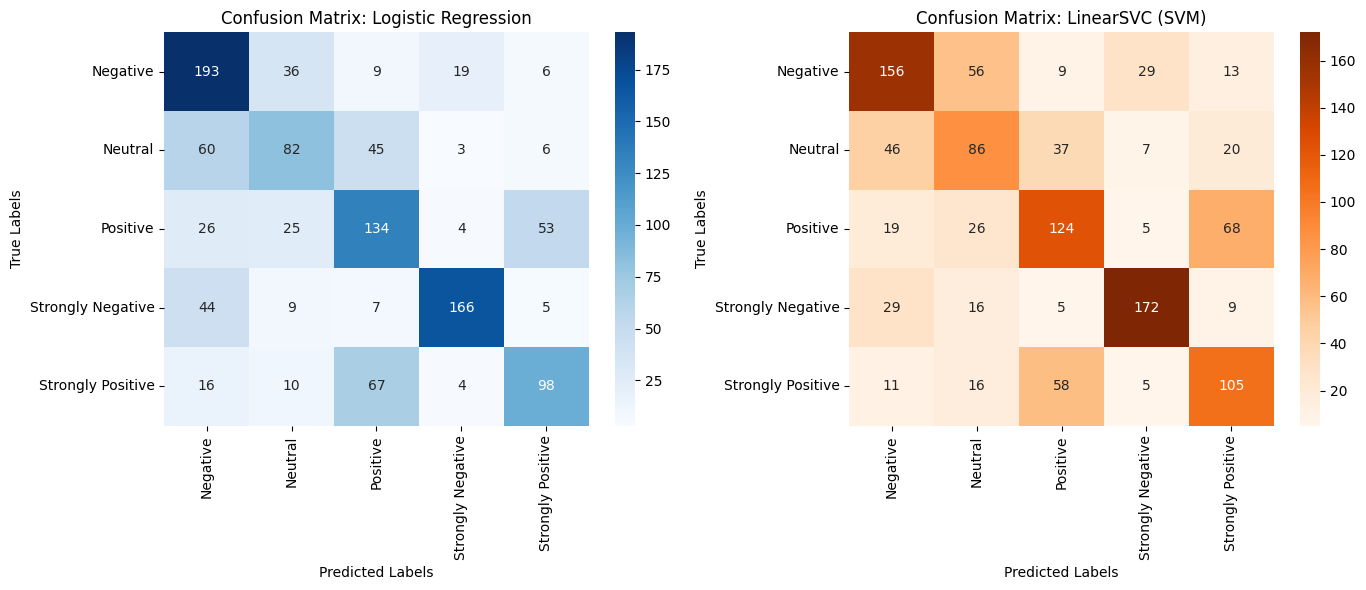

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
cm_lr = confusion_matrix(y_test_s, y_pred_s)
cm_svm = confusion_matrix(y_test_s, y_pred_svm_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Logistic Regression Confusion Matrix ---
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le_sentiment.classes_, yticklabels=le_sentiment.classes_)
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

# --- SVM (LinearSVC) Confusion Matrix ---
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=le_sentiment.classes_, yticklabels=le_sentiment.classes_)
axes[1].set_title('Confusion Matrix: LinearSVC (SVM)')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')

plt.tight_layout()
plt.show()

**Key Observations on Confusion Matrix (Sentiment):**
- LR correctly predicts more `Negative` (193 vs 156) and `Positive` (134 vs 124)
- SVM correctly predicts more `Strongly Negative` (172 vs 166) and `Strongly Positive` (105 vs 98)
- Biggest challenge: fine-grained intensity classes (`Positive` vs `Strongly Positive`, `Negative` vs `Strongly Negative`) - TF-IDF cannot capture degree of intensity

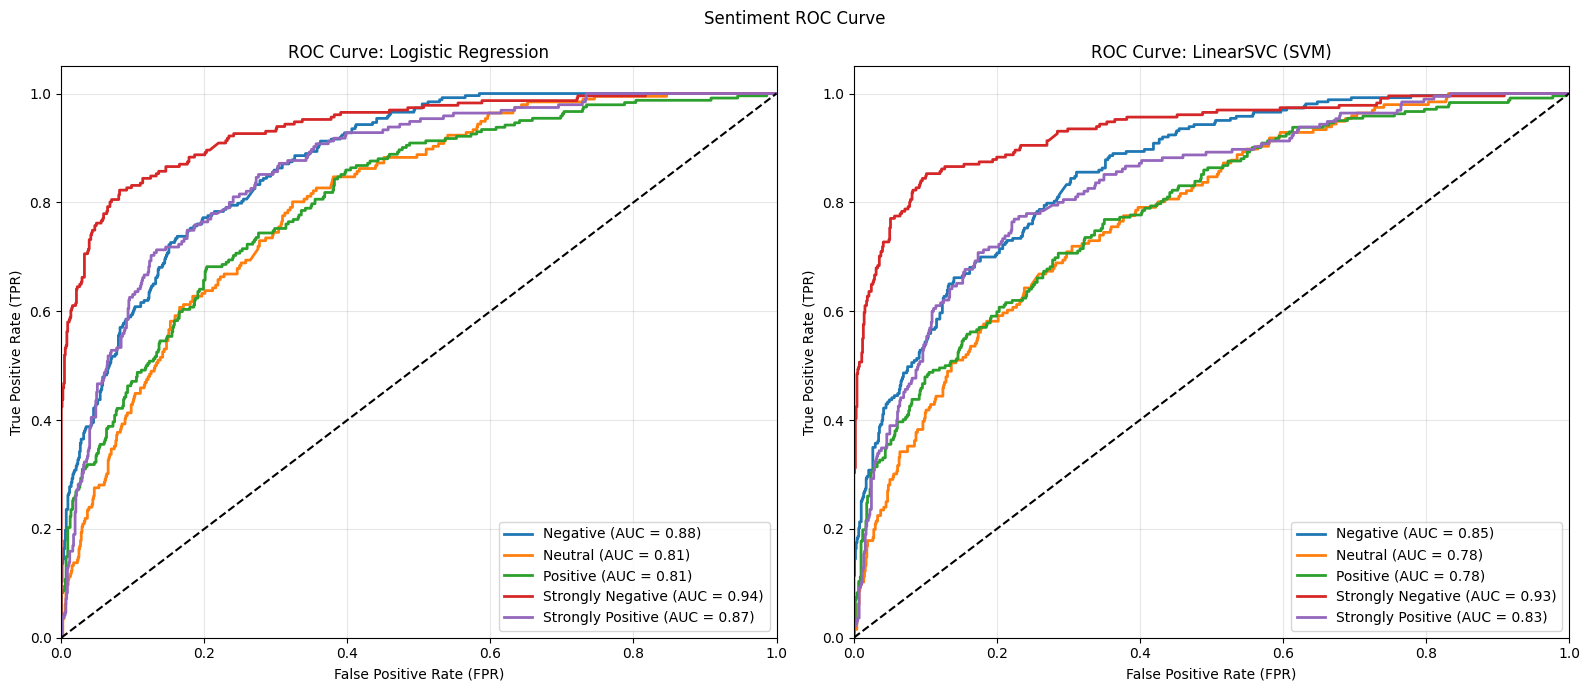

In [20]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = list(le_sentiment.classes_)
n_classes = len(classes)
y_test_binarized = label_binarize(y_test_s, classes=np.arange(n_classes))

y_score_lr = sentiment_lr_model.predict_proba(X_test_s)

y_score_svm = sentiment_svm_model.decision_function(X_test_s)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Sentiment ROC Curve")

# --- Logistic Regression ROC Curve ---
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score_lr[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})', lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('ROC Curve: Logistic Regression')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# --- SVM (LinearSVC) ROC Curve ---
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score_svm[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})', lw=2)

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('ROC Curve: LinearSVC (SVM)')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

**Key Observations on ROC Curve (Sentiment):**
- `Strongly Negative` achieves the highest AUC (LR: 0.94, SVM: 0.93) -
  distinct vocabulary like Creepy/Bullying emotion words makes it easily separable
- `Neutral` and `Positive` show the lowest AUC (0.81/0.78) -
  these classes lack strong distinguishing signal words
- LR outperforms SVM across all classes in ROC as well -
  consistent with classification report results
- All classes are well above the random baseline (AUC = 0.50),
  meaning the model has learned meaningful patterns despite low F1 scores

##**Note: Sentiment Model Comparison Summary**

| Model | CV Mean F1 | CV Std | Test F1 (Weighted) | Test Accuracy |
|---|---|---|---|---|
| Logistic Regression | 0.5937 | 0.0146 | 0.60 | 0.60 |
| LinearSVC (SVM) | 0.5849 | 0.0154 | 0.57 | 0.57 |

**Winner: Logistic Regression**

### Key Findings
- LR consistently outperforms SVM on this dataset across both CV and final test
- `Strongly Negative` is the best predicted class (F1: 0.77) - distinct vocabulary makes it easier
- `Neutral` is the hardest class (F1: 0.48) - lacks strong sentiment signal words
- `Positive` vs `Strongly Positive` confusion is expected - TF-IDF cannot capture intensity well


# **Emotion Classification**

## 5. Emotion Classification

**Target:** Predict one of 5 emotion classes:  
`Bullying` | `Creepy` | `Joyful` | `Surprise` | `Unbiased`

**Class Imbalance Note:**  
Creepy (31.9%) and Joyful (28.6%) dominate while  
Surprise (6.7%) and Bullying (10.3%) are underrepresented.  
`class_weight='balanced'` is used in all models to handle this.

Label Encoding

In [21]:
le_emotion = LabelEncoder()
y_emotion = le_emotion.fit_transform(df['Emotion'])

print("Emotion Classes:", le_emotion.classes_)
print("Sample labels:", y_emotion[:5])

Emotion Classes: ['Bullying' 'Creepy' 'Joyful' 'Surprise' 'Unbiased']
Sample labels: [1 1 0 0 4]


Train/Test Split

In [22]:
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X, y_emotion,
    test_size=0.2,
    random_state=42,
    stratify=y_emotion
)

print("Train size:", X_train_e.shape)
print("Test size:", X_test_e.shape)

Train size: (4508, 8000)
Test size: (1127, 8000)


Cross Validation

In [23]:
# Logistic Regression CV
lr_cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    X_train_e, y_train_e,
    cv=skf,
    scoring='f1_weighted'
)

print("LR CV F1 scores:", lr_cv_scores)
print("LR Mean F1:", lr_cv_scores.mean().round(4))
print("LR Std:", lr_cv_scores.std().round(4))

LR CV F1 scores: [0.67185799 0.66503678 0.66474073 0.66047337 0.67901812]
LR Mean F1: 0.6682
LR Std: 0.0065


In [24]:
svm_cv_scores = cross_val_score(
    LinearSVC(max_iter=1000, class_weight='balanced'),
    X_train_e, y_train_e,
    cv=skf,
    scoring='f1_weighted'
)

print("SVM CV F1 scores:", svm_cv_scores)
print("SVM Mean F1:", svm_cv_scores.mean().round(4))
print("SVM Std:", svm_cv_scores.std().round(4))

SVM CV F1 scores: [0.6816625  0.68055385 0.66566514 0.6541765  0.688516  ]
SVM Mean F1: 0.6741
SVM Std: 0.0124


Model Train

In [25]:
emotion_lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
emotion_lr_model.fit(X_train_e, y_train_e)

y_pred_e = emotion_lr_model.predict(X_test_e)

print(classification_report(y_test_e, y_pred_e,
      target_names=le_emotion.classes_))

              precision    recall  f1-score   support

    Bullying       0.42      0.48      0.45       116
      Creepy       0.82      0.73      0.78       359
      Joyful       0.78      0.70      0.74       323
    Surprise       0.39      0.53      0.45        77
    Unbiased       0.54      0.60      0.57       252

    accuracy                           0.65      1127
   macro avg       0.59      0.61      0.60      1127
weighted avg       0.68      0.65      0.66      1127



In [26]:
emotion_svm_model = LinearSVC(max_iter=1000, class_weight='balanced')
emotion_svm_model.fit(X_train_e, y_train_e)

y_pred_svm_e = emotion_svm_model.predict(X_test_e)

print(classification_report(y_test_e, y_pred_svm_e,
      target_names=le_emotion.classes_))

              precision    recall  f1-score   support

    Bullying       0.48      0.43      0.45       116
      Creepy       0.76      0.78      0.77       359
      Joyful       0.74      0.74      0.74       323
    Surprise       0.46      0.43      0.44        77
    Unbiased       0.56      0.57      0.56       252

    accuracy                           0.66      1127
   macro avg       0.60      0.59      0.59      1127
weighted avg       0.66      0.66      0.66      1127



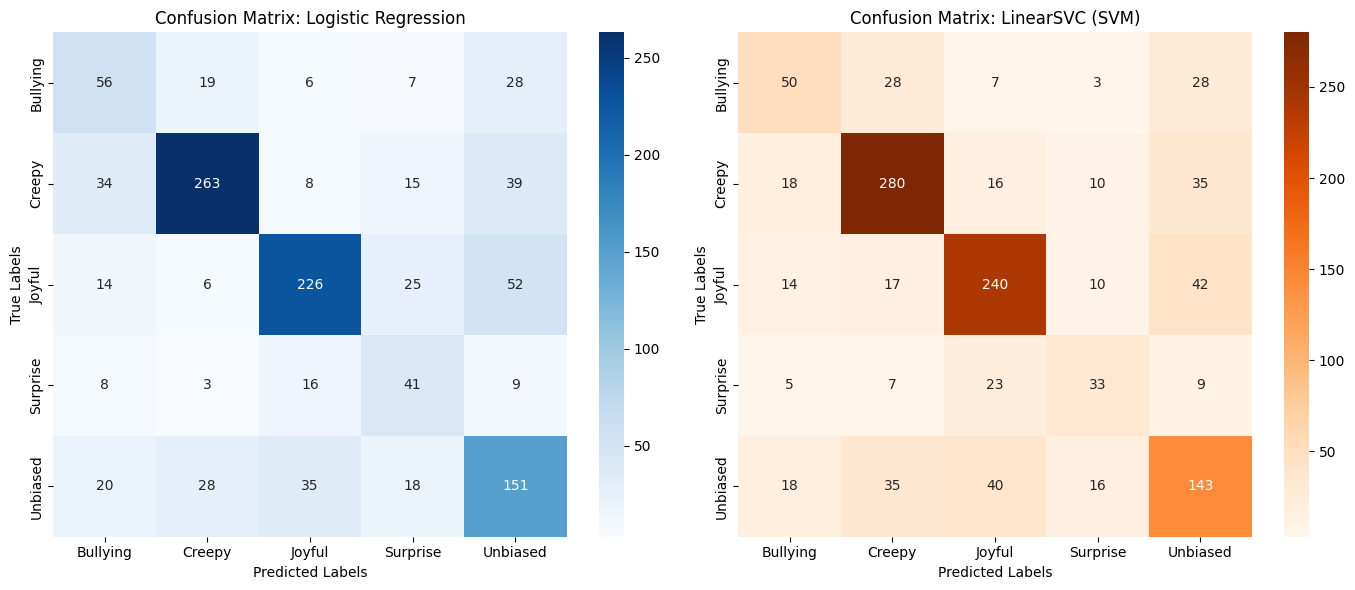

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
cm_lrs = confusion_matrix(y_test_e, y_pred_e)
cm_svms = confusion_matrix(y_test_e, y_pred_svm_e)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Logistic Regression Confusion Matrix ---
sns.heatmap(cm_lrs, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le_emotion.classes_, yticklabels=le_emotion.classes_)
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

# --- SVM (LinearSVC) Confusion Matrix ---
sns.heatmap(cm_svms, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=le_emotion.classes_, yticklabels=le_emotion.classes_)
axes[1].set_title('Confusion Matrix: LinearSVC (SVM)')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')

plt.tight_layout()
plt.show()

**Key Observations on Confusion Matrix (Emotion):**
- SVM correctly predicts more `Creepy` (280 vs 263) and `Joyful` (240 vs 226)
- LR correctly predicts more `Surprise` (41 vs 33) and `Unbiased` (151 vs 143)
- `Bullying` and `Surprise` remain the hardest classes for both models due to limited training data

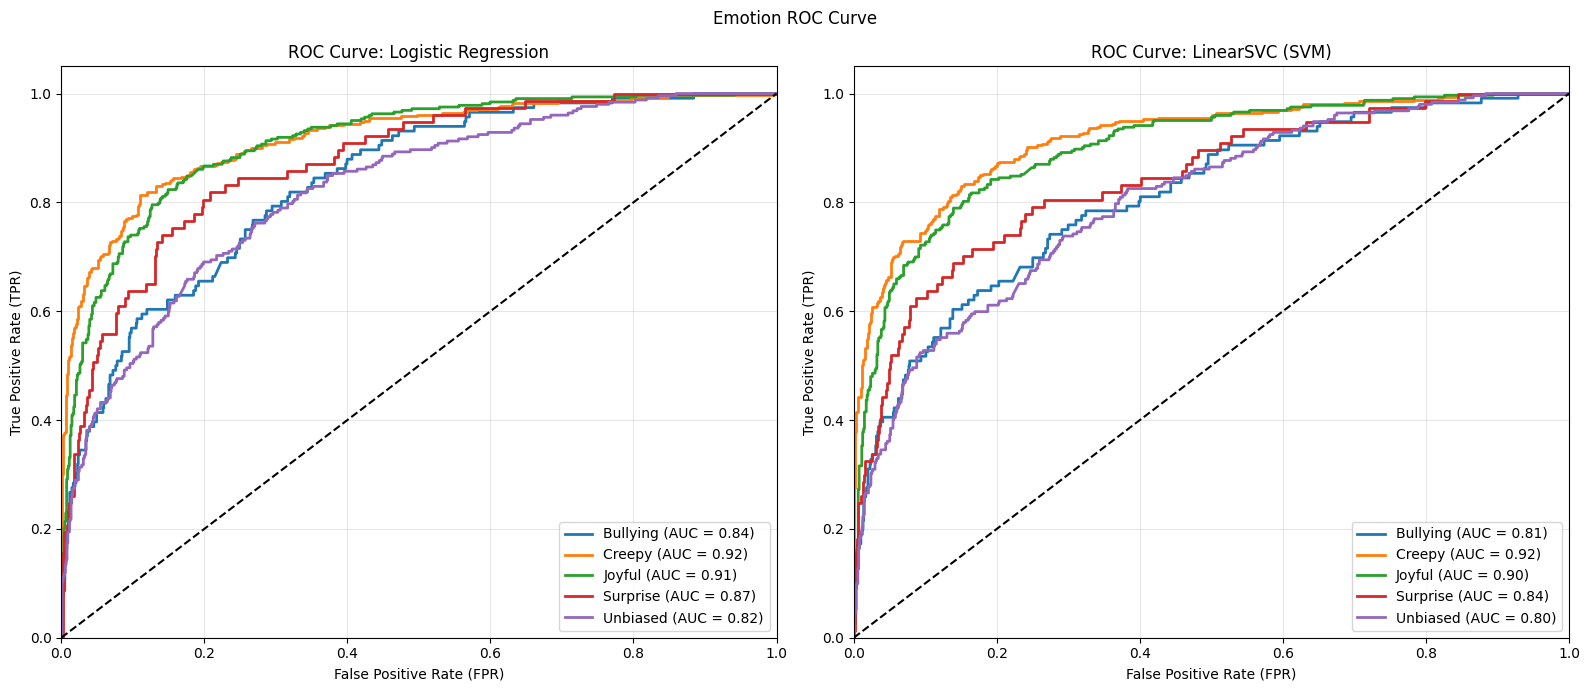

In [28]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = list(le_emotion.classes_)
n_classes = len(classes)
y_test_binarized = label_binarize(y_test_e, classes=np.arange(n_classes))

y_score_lr = emotion_lr_model.predict_proba(X_test_e)

y_score_svm = emotion_svm_model.decision_function(X_test_e)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Emotion ROC Curve")

# --- Logistic Regression ROC Curve ---
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score_lr[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})', lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('ROC Curve: Logistic Regression')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# --- SVM (LinearSVC) ROC Curve ---
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score_svm[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})', lw=2)

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('ROC Curve: LinearSVC (SVM)')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

**Key Observations on ROC Curve (Emotion):**
- `Creepy` achieves the highest AUC (0.92) in both models -
  largest class with most training samples and distinct vocabulary
- `Joyful` follows closely (LR: 0.91, SVM: 0.90) -
  strong positive signal words make it easily separable
- `Surprise` performs surprisingly well in ROC (LR: 0.87) despite low F1 (0.45) -
  model can separate it from others but struggles with precision/recall balance
- `Unbiased` shows the lowest AUC (LR: 0.82, SVM: 0.80) -
  overlaps with multiple emotion classes
- LR slightly outperforms SVM across all classes except `Creepy` where both are equal

## **Note: Emotion Model Comparison Summary**

| Model | CV Mean F1 | CV Std | Test F1 (Weighted) | Test Accuracy |
|---|---|---|---|---|
| Logistic Regression | 0.6682 | 0.0065 | 0.66 | 0.65 |
| LinearSVC (SVM) | 0.6741 | 0.0124 | 0.66 | 0.66 |

**Winner: LinearSVC (SVM)**

### Key Findings
- LR and SVM show nearly identical performance — SVM edges ahead marginally
- `Creepy` is the best predicted class (LR F1: 0.78, SVM F1: 0.77) — largest class in dataset
- `Joyful` is second best (F1: 0.74) — consistent across both models
- `Bullying` and `Surprise` are the weakest classes (F1: 0.45) — underrepresented in dataset
- LR has lower CV Std (0.0065 vs 0.0124) — more stable and consistent across folds
- SVM slightly better on accuracy but LR is more reliable overall